In this notebook, we experiment with a gating layer to a contrastive model in order to know which variables end up having less weight, and therefore, are less important when predicting $\texttt{VTE}$. The dataset that will be used is the fully imputed and pre‑processed dataset $\texttt{df\_ready}$ ($\texttt{synthetic\_clinical\_data}$ for reproductiblity). We first decide which learning rate and lambda values are best for prediction, and later on 10 experiments will be tried for 3 different values of lambda. This way, we'll see whether contrastive learning admits a gating layer in this dataset, and can decide which features are most important or not.

The accuracy results from the predictions (ROC-AUC and PR-AUC) will be saved on $\texttt{results/7.synthetic\_contrastive\_gating}$ and the final weights results will be on $\texttt{results/7.synthetic\_final\_weights}$. A summary table is provided at the end of the notebook.

# Contrastive model with feature gating

## Imports

In [1]:
import numpy as np
import pandas as pd
import os

import gc

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

## Data loading

In [2]:
path_data = "dataframes\synthetic_clinical_data.csv"
df = pd.read_csv(path_data)

X = df.drop(columns=["VTE"]).values.astype(np.float32)
y = df["VTE"].values.astype(np.int64)

test_size = 0.25
random_state = 42

d_init = X.shape[1]
d_init

39

### Create the $\texttt{.csv}$ file

In [3]:
results_path = "results/7.synthetic_contrastive_gating.csv"

# Check if file exists
if not os.path.exists(results_path):
    print("File not found. Creating new results file...")

    df_results = pd.DataFrame(columns=[
        "model",
        "random_state",
        "test_size",
        "n_epochs",
        "margin",
        "batch_size",
        "learning_rate",
        "weight_decay",
        "scheduler_step_size",
        "scheduler_gamma",
        "lambda_l1",
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "n_layers"
    ])

    df_results.to_csv(results_path, index=False)
else:
    print("Results file already exists.")
    df_results = pd.read_csv(results_path)

df_results.head()

Results file already exists.


,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,lambda_l1,ROC-AUC,PR-AUC,Accuracy,n_layers
0,Contrastive+Gating_tune,0,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.1,0.547018,0.294269,0.659847,1
1,Contrastive+Gating_tune,5,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.1,0.571714,0.334192,0.664962,1
2,Contrastive+Gating_tune,42,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.1,0.521898,0.298802,0.667519,1
3,Contrastive+Gating_tune,0,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.2,0.515215,0.287633,0.652174,1
4,Contrastive+Gating_tune,5,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.2,0.547815,0.314767,0.672634,1


In [4]:
weights_path = "results/7.synthetic_final_weights.csv"

# Check if file exists
if not os.path.exists(weights_path):
    print("File not found. Creating new results file...")

    df_weights = pd.DataFrame(columns=[
        "learning_rate",
        "weight_decay",
        "lambda_l1",
        "n_epochs",
        "n_layers",
        "margin",
        "test_size",
        "feature",
        "avg_weight"
    ])

    df_weights.to_csv(weights_path, index=False)
else:
    print("Results file already exists.")
    df_weights = pd.read_csv(weights_path)

df_weights.head()

Results file already exists.


,learning_rate,weight_decay,lambda_l1,n_epochs,n_layers,margin,test_size,feature,avg_weight
0,0.001,1.000000e-08,0.1,100,1,0.3,0.25,primary_tumor_Colorectal,0.088276
1,0.001,1.000000e-08,0.1,100,1,0.3,0.25,age_cancer_dx,0.087095
2,0.001,1.000000e-08,0.1,100,1,0.3,0.25,tobacco_use_Never has smoked,0.077467
3,0.001,1.000000e-08,0.1,100,1,0.3,0.25,performance_status,0.075992
4,0.001,1.000000e-08,0.1,100,1,0.3,0.25,dyslipidemia,0.075839


## Kernel functions

### Dataset classes

In [5]:
from utils import PairDatasetBalanced

### Gating layer

In [6]:
from utils import GatingLayer

### Model + loss

In [7]:
from utils import DeepKernel_gating, hinge_loss

### Training / evaluation loops

In [8]:
from utils import train_one_epoch_gating, eval_one_epoch

### Fit

In [9]:
from utils import fit_gating, plot_history, transform_dataset_contrastive

## Training setup

### Model variables

In [10]:
model_name="Contrastive+Gating_tune"
n_layers=1

FOLDS=4

bsize = 32
d_out = 16

learning_rate = 1e-3
weight_decay = 1e-8   # 1e-8

scheduler_step_size = 300
scheduler_gamma = 0.01

epochs = 100
margin = 0.3    

# scheduler = None    # disable for now

# L1 penalty
lambda_l1 = 0.05  # strength of an L1 regularization term   

#### Device and empty cache

In [11]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using {device} device")

Using cpu device


#### Define the StratifiedShuffleSplit

In [12]:
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=random_state)

all_preds = []
all_y = []
all_probs = []

all_gating_weights = []

## Training the model


Fold 1


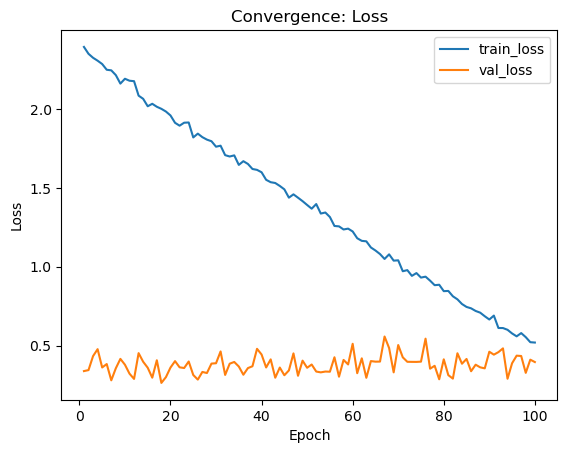

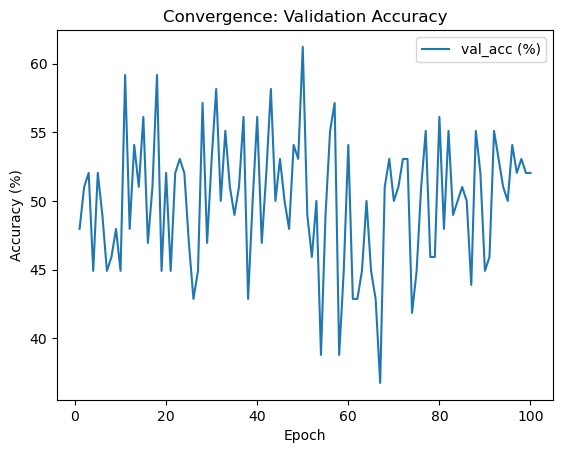


Fold 2


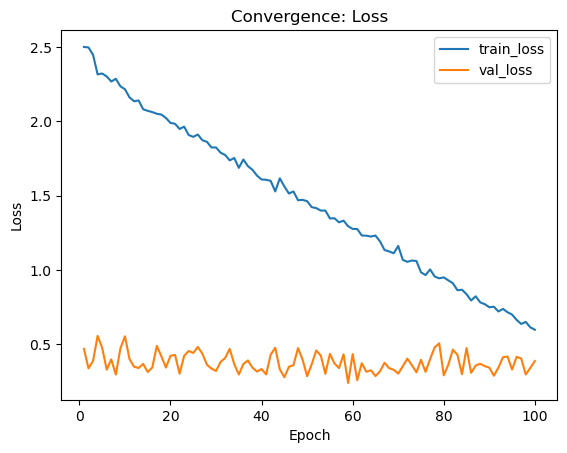

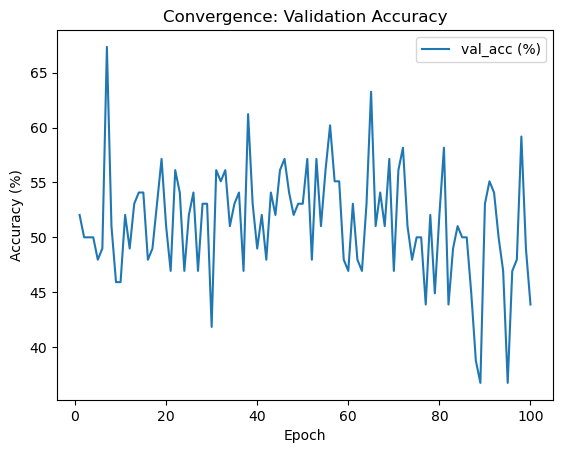


Fold 3


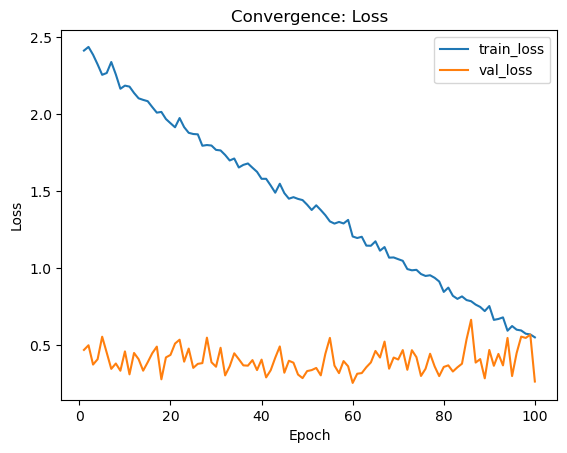

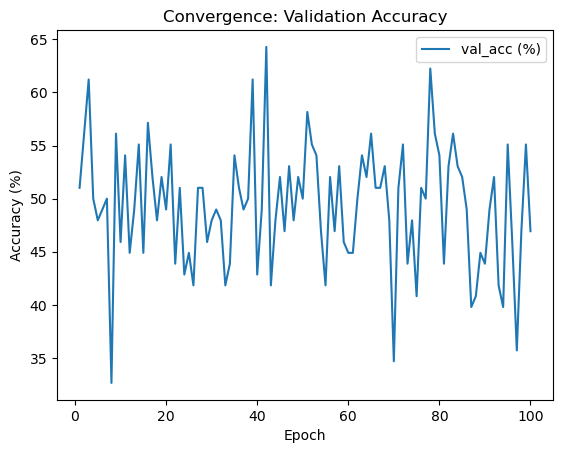


Fold 4


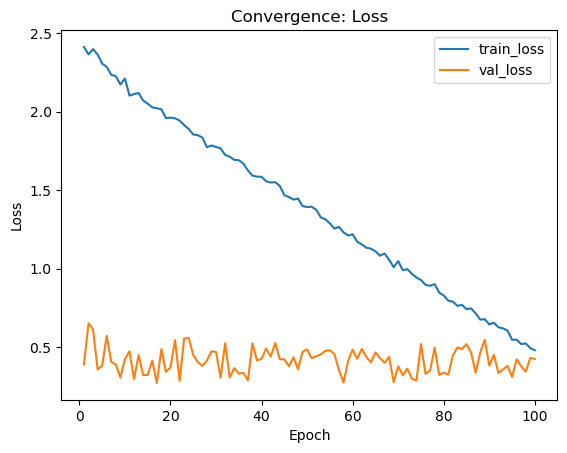

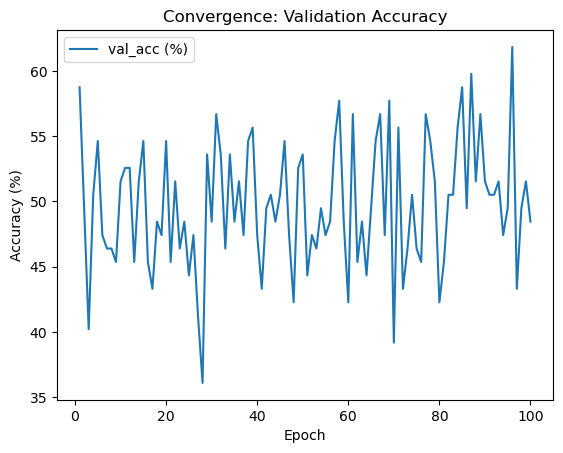

In [13]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}")

    # Split the data into training and test sets for this fold
    # Flip train and test
    X_train_np = X[train_idx]
    X_test_np  = X[test_idx]
    y_train_np = y[train_idx]
    y_test_np  = y[test_idx]
    
    # Standardize (fit on train only)
    scaler = StandardScaler()                       # computes X_scaled = (X - mu) / sigma
    X_train_np = scaler.fit_transform(X_train_np)   # applied only on the training set
    X_test_np  = scaler.transform(X_test_np)   # is applied on the test set using training statistics
    # This avoids data leakage
    # Now all features have mean 0 and variance 1 (based on training data only)
    # Neural networks train much better with standardized inputs
    
    # Convert NumPy arrays into PyTorch tensors
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    y_train = torch.tensor(y_train_np, dtype=torch.long)
    X_test = torch.tensor(X_test_np, dtype=torch.float32)
    y_test = torch.tensor(y_test_np, dtype=torch.long)
    
    # Contrastive datasets/loaders
    # Each item returned by the dataset is a pair of samples (xa, xb) and their labels (ya, yb)
    # generate positive pairs (same class) and negative pairs (different class) in a controlled ratio
    train_dataset = PairDatasetBalanced(X_train, y_train)
    test_dataset = PairDatasetBalanced(X_test, y_test)

    # groups samples into batches of size bsize, shuffles the training dataset, feeds batches to the model efficiently
    pair_train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)
    pair_test_loader = DataLoader(test_dataset, batch_size=bsize)
    
    # Original loaders (for embeddings)
    # Return single samples (x, y) (no pairing, no contrastive sampling, no positive/negative logic)
    # To evaluate accuracy, F1, ROC-AUC, etc.
    train_original = TensorDataset(X_train, y_train)
    test_original = TensorDataset(X_test, y_test)
    original_train_loader = DataLoader(train_original, batch_size=bsize)
    original_test_loader = DataLoader(test_original, batch_size=bsize)

    # Free memory
    gc.collect()
    if device == "mps":
        torch.mps.empty_cache()
    if device == "cuda":
        torch.cuda.empty_cache()

    # learns a representation where “similar patients” are close and “different patients” are far
    model = DeepKernel_gating(d_init, d_out).to(device)

    # Creates an optimizer that will update the model parameters
    # AdamW is a variant of Adam that decouples weight decay from gradient updates
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # learning rate scheduler that will reduce the learning rate during training
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step_size,
        gamma=scheduler_gamma
    )

    # Train the embedding model using pairwise hinge loss
    loss_fn = hinge_loss
    
    history = fit_gating(
        pair_train_loader, pair_test_loader,
        model, loss_fn, optimizer, device,
        epochs=epochs, margin=margin, lambda_l1=lambda_l1, threshold=0.2,
        scheduler=scheduler,
        verbose=False
    )

    w_fold = model.gating.v.detach().cpu().numpy()
    all_gating_weights.append(w_fold)

    # Plot training curves
    plot_history(history)

    # Transform the original dataset into embeddings
    X_t, y_t = transform_dataset_contrastive(model, original_train_loader, device)
    X_ts, y_ts = transform_dataset_contrastive(model, original_test_loader, device)

    # Use those embeddings for classification
    # random forest because embeddings are low‑dimensional (16 features), 
        # they are already structured (positives close, negatives far),
        # handles small datasets well, robust to noise and give probability outputs
    clf = RandomForestClassifier(
        n_estimators=101,
        max_depth=None,
        min_samples_split=2,
        random_state=random_state,
        class_weight="balanced"  # important for imbalanced VTE, ensures minority class is not ignored.
    )
    
    clf.fit(X_t, y_t)
    
    # This is supervised learning, but on top of the learned embedding space:
    # The contrastive model learns the geometry.
    # The classifier learns the decision boundary.

    yhat = clf.predict(X_ts)
    yhat_proba = clf.predict_proba(X_ts)

    all_preds.append(yhat)
    all_y.append(y_ts)
    all_probs.append(yhat_proba)

## Gating results

In [14]:
all_gating_weights = np.array(all_gating_weights)   # shape: (FOLDS, n_features)
avg_weights = all_gating_weights.mean(axis=0)

feature_names = df.columns.drop("VTE")

In [15]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "avg_weight": avg_weights
}).sort_values("avg_weight", ascending=False)

print(importance_df)

                               feature  avg_weight
26            tumor_surgically_removed    0.228569
34            primary_tumor_Colorectal    0.207839
19                   diabetes_mellitus    0.204597
20                        dyslipidemia    0.204242
18               arterial_hypertension    0.203988
6                rs4524_n_risk_alleles    0.202243
27                     catheter_device    0.198889
3   grade_histological_differentiation    0.195589
7                rs6003_n_risk_alleles    0.194591
13               rs5985_n_risk_alleles    0.189542
2                   performance_status    0.189380
4            rs11696364_n_risk_alleles    0.187809
0                        age_cancer_dx    0.186475
36                 primary_tumor_NSCLC    0.185644
29           tobacco_use_Active smoker    0.185211
38            primary_tumor_Pancreatic    0.184942
8             rs2227631_n_risk_alleles    0.183807
35               primary_tumor_Gastric    0.182801
1                              

## Results and predictions

In [16]:
all_preds = np.concatenate(all_preds)
all_y = np.concatenate(all_y)
all_probs = np.concatenate(all_probs)

### ROC, Precision-Recall curves and accuracy

In [17]:
roc_auc = roc_auc_score(all_y, all_probs[:, 1])
pr_auc = average_precision_score(all_y, all_probs[:, 1])
acc = accuracy_score(all_y, all_preds)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Accuracy:", acc)

ROC-AUC: 0.4979306601533347
PR-AUC: 0.26408294025711043
Accuracy: 0.6572890025575447


In [18]:
print(classification_report(all_y, all_preds))

              precision    recall  f1-score   support

           0       0.75      0.80      0.78       289
           1       0.30      0.25      0.27       102

    accuracy                           0.66       391
   macro avg       0.53      0.52      0.52       391
weighted avg       0.63      0.66      0.64       391



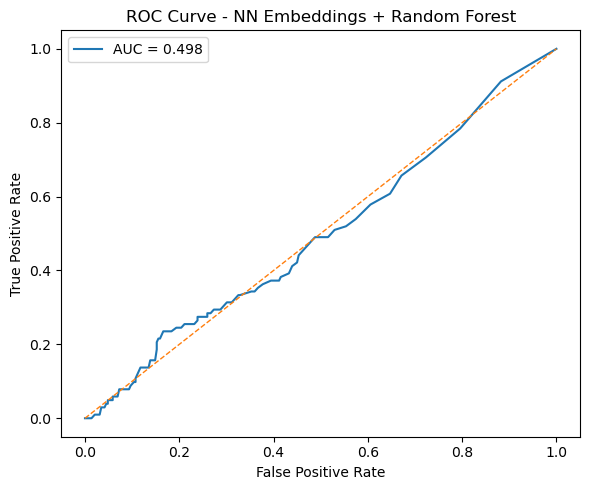

In [19]:
# --- ROC CURVE ---
fpr, tpr, _ = roc_curve(all_y, all_probs[:, 1])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NN Embeddings + Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

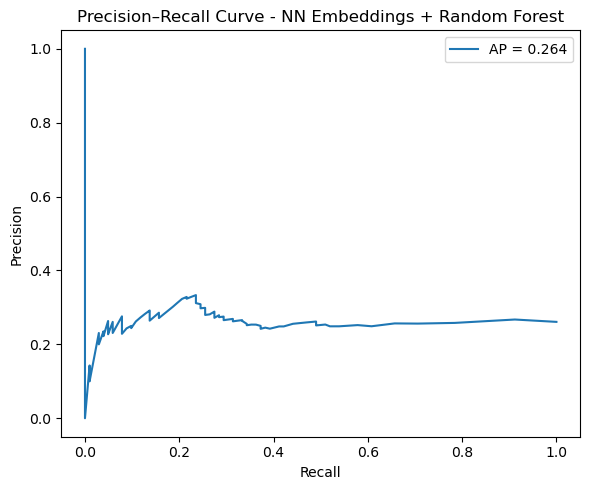

In [20]:
# --- PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(all_y, all_probs[:, 1])

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - NN Embeddings + Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

# Save results to the $\texttt{.csv}$

In [21]:
df_results.loc[len(df_results)] = [
    model_name,
    random_state,
    test_size,
    epochs,
    margin,
    bsize,
    learning_rate,
    weight_decay,
    scheduler_step_size,
    scheduler_gamma,
    lambda_l1,
    roc_auc,
    pr_auc,
    acc,
    n_layers
]

df_results.to_csv(results_path, index=False)
df_results.tail()

,model,random_state,test_size,n_epochs,margin,batch_size,learning_rate,weight_decay,scheduler_step_size,scheduler_gamma,lambda_l1,ROC-AUC,PR-AUC,Accuracy,n_layers
4,Contrastive+Gating_tune,5,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.20,0.547815,0.314767,0.672634,1
5,Contrastive+Gating_tune,42,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.20,0.470130,0.255140,0.644501,1
6,Contrastive+Gating_tune,0,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.05,0.539436,0.293439,0.672634,1
7,Contrastive+Gating_tune,5,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.05,0.537367,0.296458,0.664962,1
8,Contrastive+Gating_tune,42,0.25,100,0.3,32,0.001,1.000000e-08,300,0.01,0.05,0.497931,0.264083,0.657289,1


In [22]:
df_new = pd.DataFrame({
    "learning_rate": [learning_rate] * len(importance_df),
    "weight_decay": [weight_decay] * len(importance_df),
    "lambda_l1": [lambda_l1] * len(importance_df),
    "n_epochs": [epochs] * len(importance_df),
    "n_layers": [n_layers] * len(importance_df),
    "margin": [margin] * len(importance_df),
    "test_size": [test_size] * len(importance_df),
    "feature": importance_df["feature"].values,
    "avg_weight": importance_df["avg_weight"].values
})

df_weights = pd.concat([df_weights, df_new], ignore_index=True)
df_weights.to_csv(weights_path, index=False)

df_weights.tail()

,learning_rate,weight_decay,lambda_l1,n_epochs,n_layers,margin,test_size,feature,avg_weight
346,0.001,1.000000e-08,0.05,100,1,0.3,0.25,chronic_cardiac_insufficiency,0.055342
347,0.001,1.000000e-08,0.05,100,1,0.3,0.25,previous_vte,0.000010
348,0.001,1.000000e-08,0.05,100,1,0.3,0.25,rs268_n_risk_alleles,0.000010
349,0.001,1.000000e-08,0.05,100,1,0.3,0.25,rs2232698_n_risk_alleles,0.000010
350,0.001,1.000000e-08,0.05,100,1,0.3,0.25,rs6025_n_risk_alleles,0.000010


# Summary table

### Accuracy results

In [23]:
summary = (
    df_results
    .groupby(["model", "learning_rate", "lambda_l1", "n_layers"])[["ROC-AUC", "PR-AUC", "Accuracy"]]
    .mean()
    .reset_index()
)

summary

,model,learning_rate,lambda_l1,n_layers,ROC-AUC,PR-AUC,Accuracy
0,Contrastive+Gating_tune,0.001,0.05,1,0.524911,0.284660,0.664962
1,Contrastive+Gating_tune,0.001,0.10,1,0.546877,0.309087,0.664109
2,Contrastive+Gating_tune,0.001,0.20,1,0.511053,0.285847,0.656436


### Final weights

In [24]:
grouped = (
    df_weights
    .groupby(["feature", "lambda_l1"])["avg_weight"]
    .mean()
    .reset_index()
)

t01 = grouped[grouped["lambda_l1"] == 0.1][["feature", "avg_weight"]] \
        .sort_values("avg_weight", ascending=False) \
        .reset_index(drop=True)

t02 = grouped[grouped["lambda_l1"] == 0.2][["feature", "avg_weight"]] \
        .sort_values("avg_weight", ascending=False) \
        .reset_index(drop=True)

t03 = grouped[grouped["lambda_l1"] == 0.05][["feature", "avg_weight"]] \
        .sort_values("avg_weight", ascending=False) \
        .reset_index(drop=True)

final_table = pd.concat(
    [
        t01.rename(columns={"feature": "feature_0.1", "avg_weight": "avg_weight_0.1"}),
        t02.rename(columns={"feature": "feature_0.2", "avg_weight": "avg_weight_0.2"}),
        t03.rename(columns={"feature": "feature_0.3", "avg_weight": "avg_weight_0.3"})
    ],
    axis=1
)

final_table

,feature_0.1,avg_weight_0.1,feature_0.2,avg_weight_0.2,feature_0.3,avg_weight_0.3
0,primary_tumor_Colorectal,0.080052,performance_status,0.032337,tumor_surgically_removed,0.203853
1,age_cancer_dx,0.079176,tumor_surgically_removed,0.030798,arterial_hypertension,0.196039
2,performance_status,0.079131,rs5985_n_risk_alleles,0.030788,primary_tumor_Colorectal,0.195766
3,rs169713_n_risk_alleles,0.077541,rs169713_n_risk_alleles,0.030732,age_cancer_dx,0.191513
4,rs5985_n_risk_alleles,0.077284,tobacco_use_Never has smoked,0.029976,performance_status,0.189766
5,copd,0.075995,family_background_vte,0.029911,rs5985_n_risk_alleles,0.180345
6,tumor_surgically_removed,0.075900,catheter_device,0.029688,tobacco_use_Never has smoked,0.179848
7,arterial_hypertension,0.075167,rs4524_n_risk_alleles,0.028530,dyslipidemia,0.179419
8,dyslipidemia,0.073875,primary_tumor_Bile duct,0.028352,rs2227631_n_risk_alleles,0.178999
9,rs4524_n_risk_alleles,0.072697,rs11696364_n_risk_alleles,0.028224,primary_tumor_Pancreatic,0.176802
